In [1]:
from pathlib import Path
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from PIL import Image

# Setup
project_root = Path.cwd()
yolo_checkpoint = project_root / 'tracking_baseline' / 'train' / 'runs' / 'yolo' / 'azure_full_v12' / 'weights' / 'best.pt'
# Visualization output directory
viz_dir = project_root / 'visual_comparison' / 'layer_visualizations'
viz_dir.mkdir(parents=True, exist_ok=True)

test_seq = 'SNMOT-122'
img_dir = project_root / 'data' / 'tracking-2023' / 'test' / test_seq / 'img1'

# Load model
model = YOLO(str(yolo_checkpoint))
print(f"✓ Loaded YOLOv8 from {yolo_checkpoint.name}")

# Select a frame with good detection (from your optimal sequence)
frame_id = 100
img_path = img_dir / f"{frame_id:06d}.jpg"

# Load and preprocess image
img_bgr = cv2.imread(str(img_path))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
original_size = img_rgb.shape[:2]

print(f"Original image size: {original_size}")
print(f"Model input size: 832x832")

✓ Loaded YOLOv8 from best.pt
Original image size: (1080, 1920)
Model input size: 832x832


## Step 1: Original Input Image

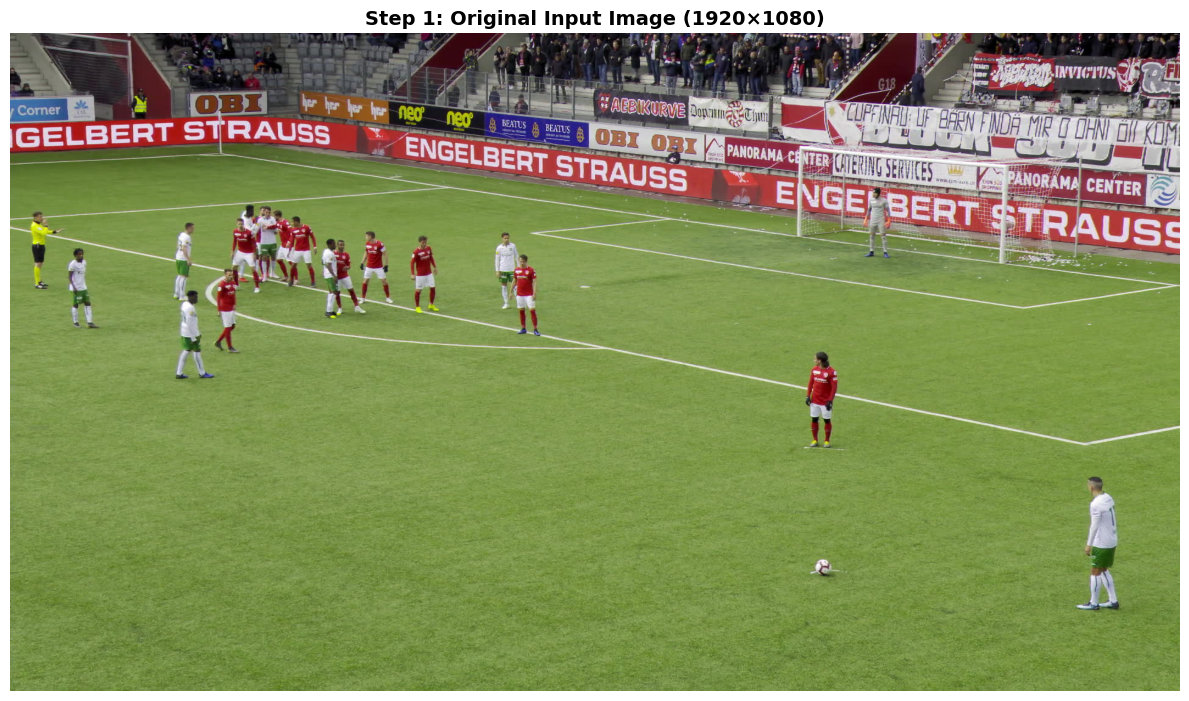

✓ Saved: /Users/yashpatel/Documents/Bocconi/Classes/Year 2/Semester 1/Deep Learning for Computer Vision/Project/Code/visual_comparison/layer_visualizations/layer_viz_1_original.png


In [2]:
# Display original image
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.imshow(img_rgb)
ax.set_title('Step 1: Original Input Image (1920×1080)', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig(viz_dir / 'layer_viz_1_original.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved:", viz_dir / 'layer_viz_1_original.png')

## Step 2: Preprocessed Input (Resized & Normalized)

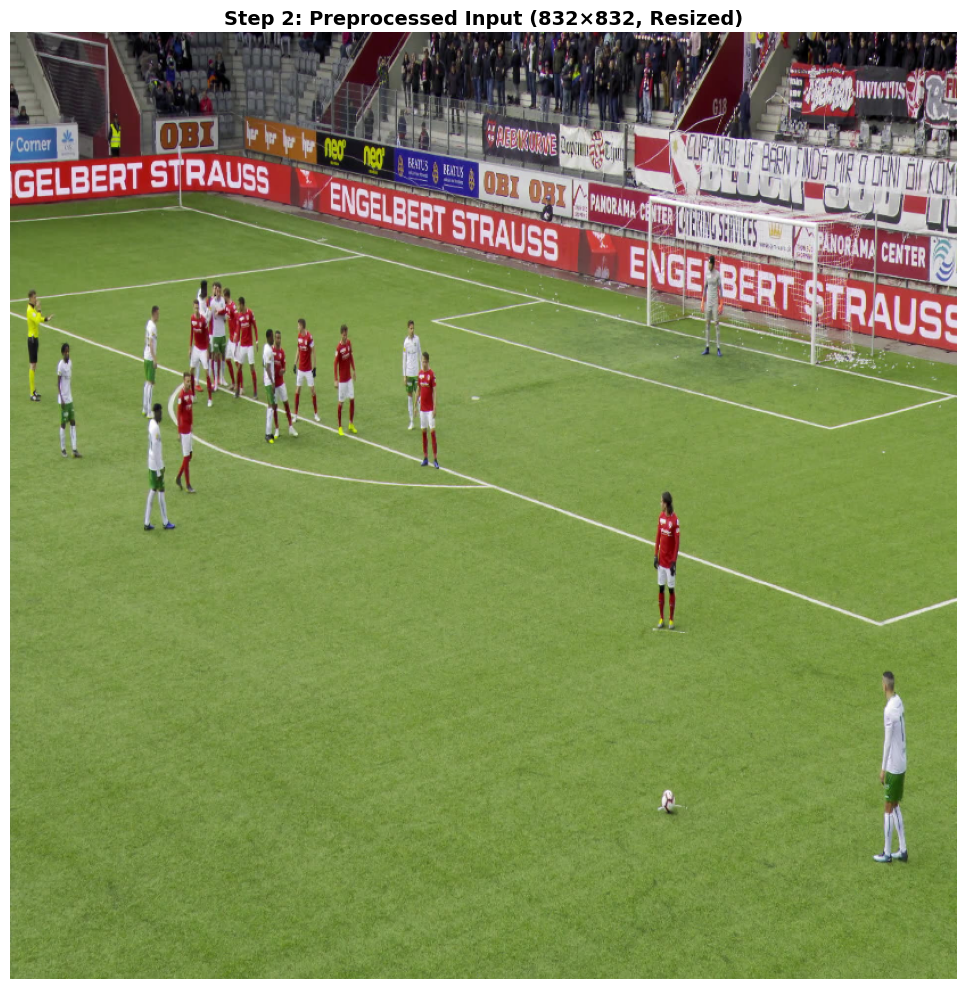

✓ Saved: /Users/yashpatel/Documents/Bocconi/Classes/Year 2/Semester 1/Deep Learning for Computer Vision/Project/Code/visual_comparison/layer_visualizations/layer_viz_2_preprocessed.png


In [3]:
# Show preprocessed input (what actually goes into the network)
# Simple resize to 832x832 (what the model expects)
img_resized = cv2.resize(img_rgb, (832, 832))

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(img_resized)
ax.set_title('Step 2: Preprocessed Input (832×832, Resized)', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig(viz_dir / 'layer_viz_2_preprocessed.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved:", viz_dir / 'layer_viz_2_preprocessed.png')

## Step 3: Extract Feature Maps from Key Layers

We'll hook into the YOLOv8 backbone to extract intermediate representations.

In [4]:
# Extract features at different depths
features = {}

def hook_fn(name):
    def hook(module, input, output):
        features[name] = output.detach()
    return hook

# Register hooks on key backbone layers
# YOLOv8 backbone: Conv → C2f blocks → SPPF
hooks = []
layer_names = []

# Access the actual PyTorch model inside YOLO wrapper
pytorch_model = model.model

# Hook early layer (after first conv)
hooks.append(pytorch_model.model[0].register_forward_hook(hook_fn('early_conv')))
layer_names.append('early_conv')

# Hook middle layers (C2f blocks at different scales)
hooks.append(pytorch_model.model[2].register_forward_hook(hook_fn('mid_c2f_1')))
layer_names.append('mid_c2f_1')

hooks.append(pytorch_model.model[4].register_forward_hook(hook_fn('mid_c2f_2')))
layer_names.append('mid_c2f_2')

hooks.append(pytorch_model.model[6].register_forward_hook(hook_fn('mid_c2f_3')))
layer_names.append('mid_c2f_3')

# Hook deep layer (SPPF)
hooks.append(pytorch_model.model[9].register_forward_hook(hook_fn('deep_sppf')))
layer_names.append('deep_sppf')

print(f"Registered hooks on {len(hooks)} layers")

# Run inference to populate features
with torch.no_grad():
    results = model.predict(str(img_path), imgsz=832, verbose=False)

# Remove hooks
for hook in hooks:
    hook.remove()

print(f"\nExtracted features from {len(features)} layers:")
for name, feat in features.items():
    print(f"  {name}: {feat.shape}")

Registered hooks on 5 layers

Extracted features from 5 layers:
  early_conv: torch.Size([1, 16, 240, 416])
  mid_c2f_1: torch.Size([1, 32, 120, 208])
  mid_c2f_2: torch.Size([1, 64, 60, 104])
  mid_c2f_3: torch.Size([1, 128, 30, 52])
  deep_sppf: torch.Size([1, 256, 15, 26])

Extracted features from 5 layers:
  early_conv: torch.Size([1, 16, 240, 416])
  mid_c2f_1: torch.Size([1, 32, 120, 208])
  mid_c2f_2: torch.Size([1, 64, 60, 104])
  mid_c2f_3: torch.Size([1, 128, 30, 52])
  deep_sppf: torch.Size([1, 256, 15, 26])


## Step 4: Visualize Feature Maps at Different Layers

✓ Saved: /Users/yashpatel/Documents/Bocconi/Classes/Year 2/Semester 1/Deep Learning for Computer Vision/Project/Code/visual_comparison/layer_visualizations/layer_viz_3a_early_conv.png


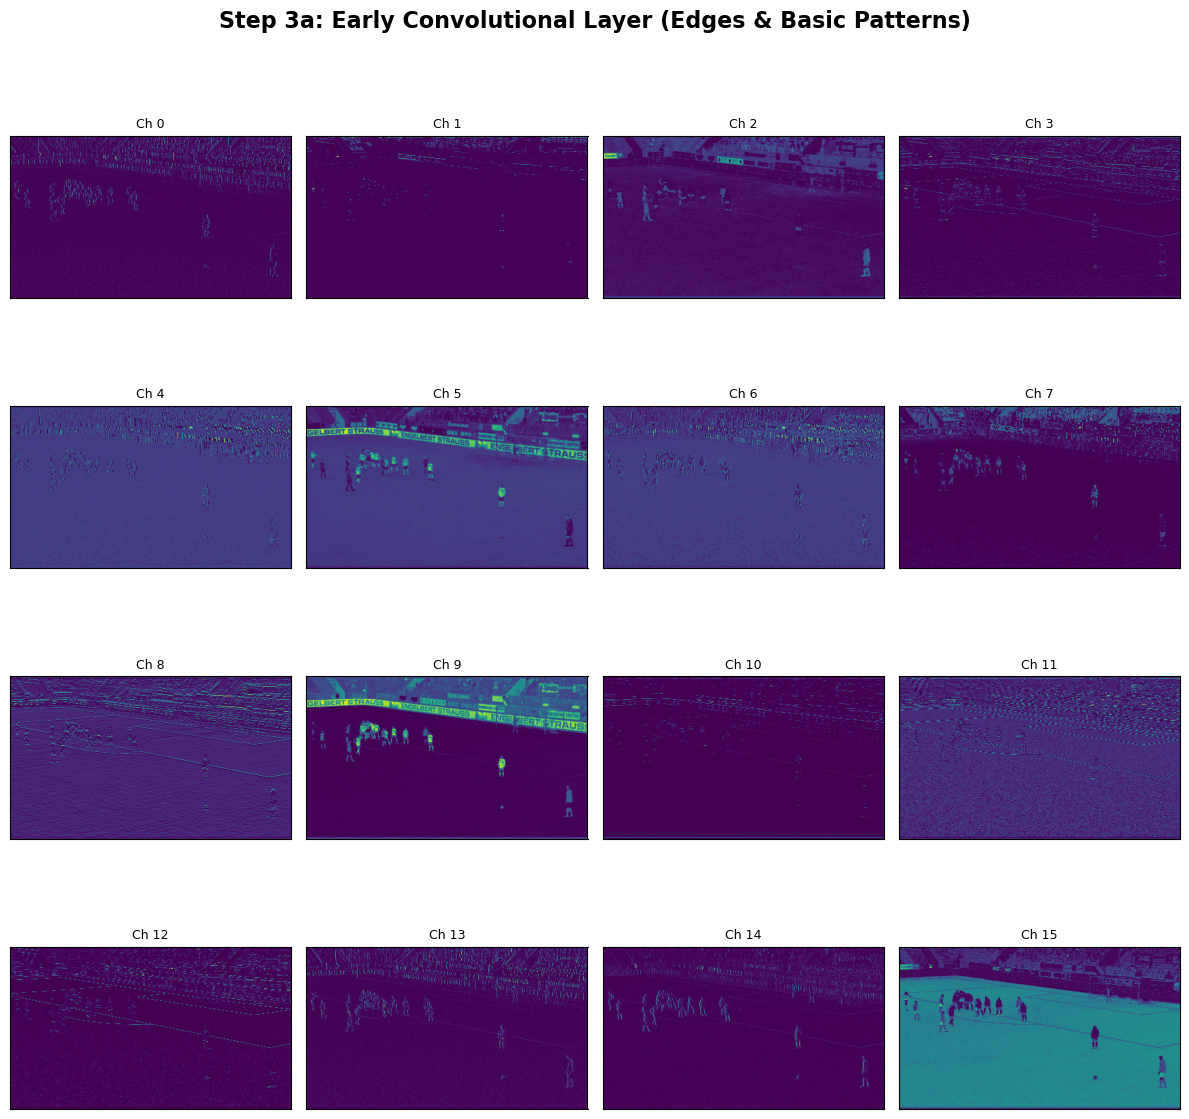

✓ Saved: /Users/yashpatel/Documents/Bocconi/Classes/Year 2/Semester 1/Deep Learning for Computer Vision/Project/Code/visual_comparison/layer_visualizations/layer_viz_3b_mid_features.png


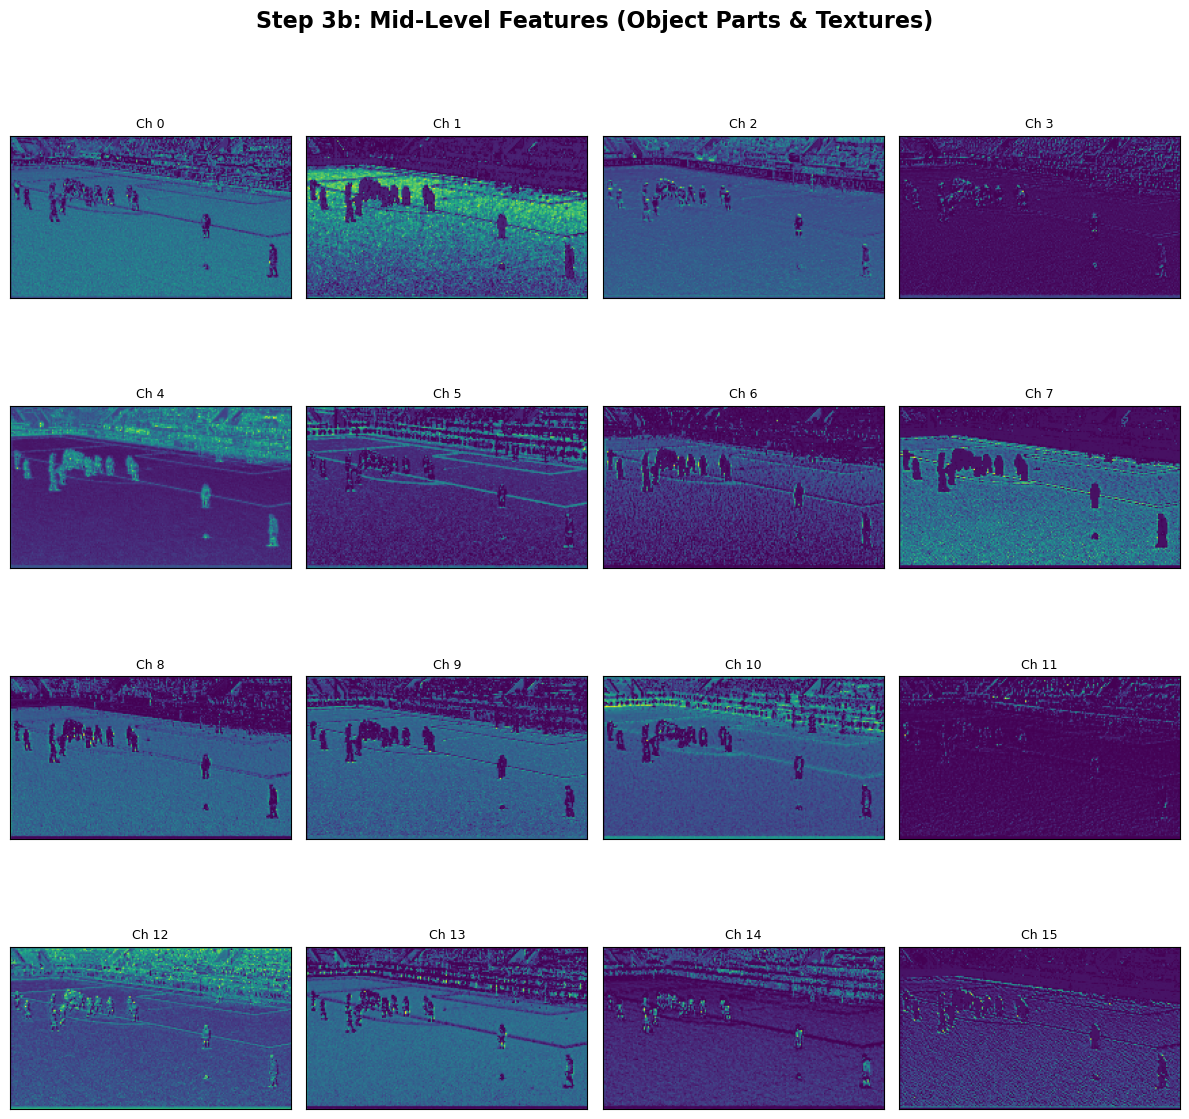

✓ Saved: /Users/yashpatel/Documents/Bocconi/Classes/Year 2/Semester 1/Deep Learning for Computer Vision/Project/Code/visual_comparison/layer_visualizations/layer_viz_3c_high_features.png


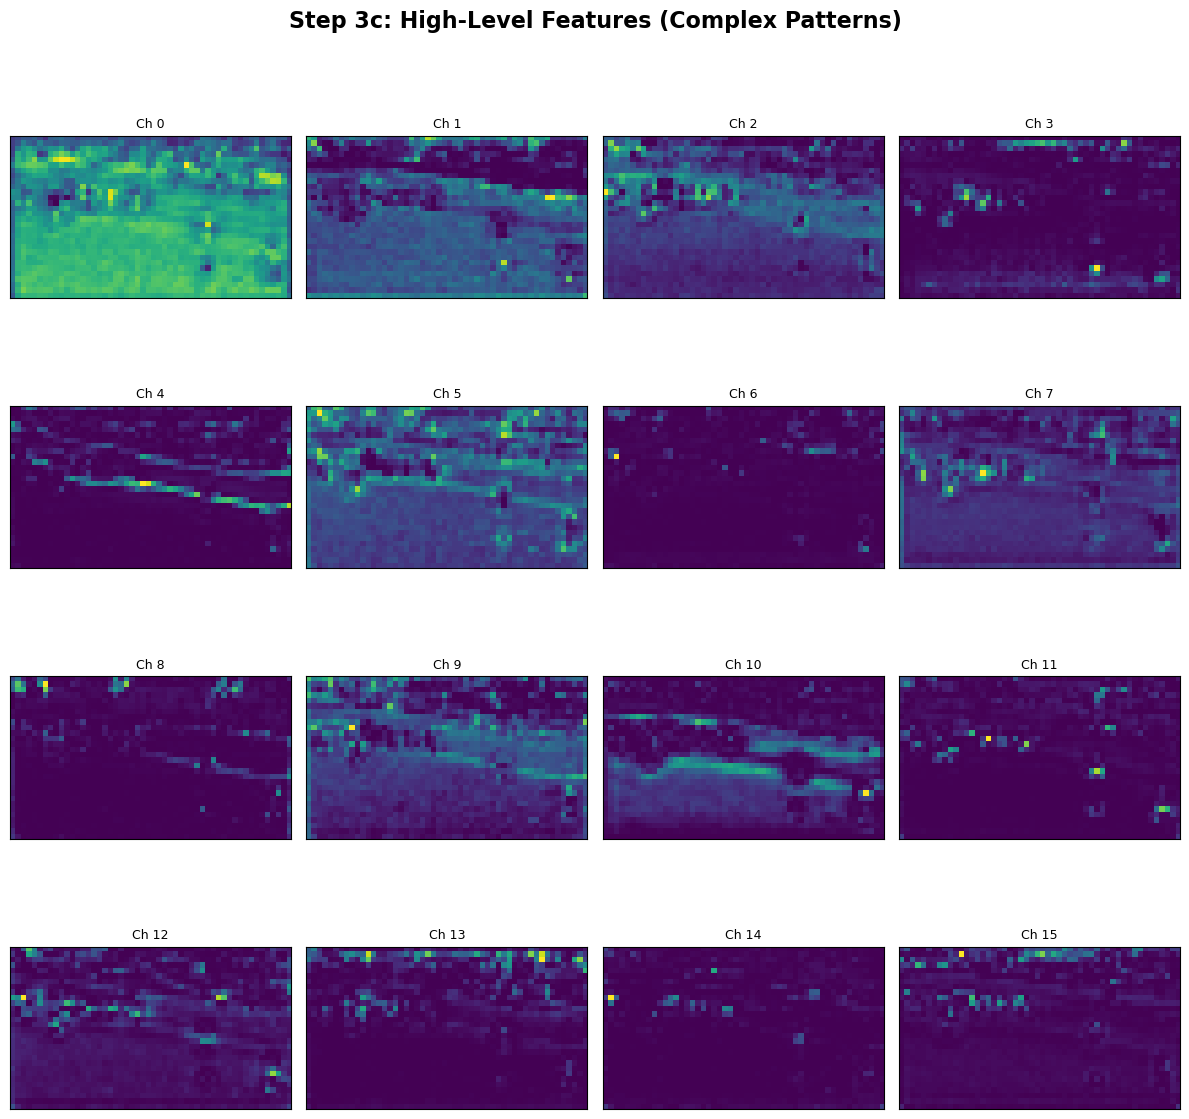

✓ Saved: /Users/yashpatel/Documents/Bocconi/Classes/Year 2/Semester 1/Deep Learning for Computer Vision/Project/Code/visual_comparison/layer_visualizations/layer_viz_3d_deep_features.png


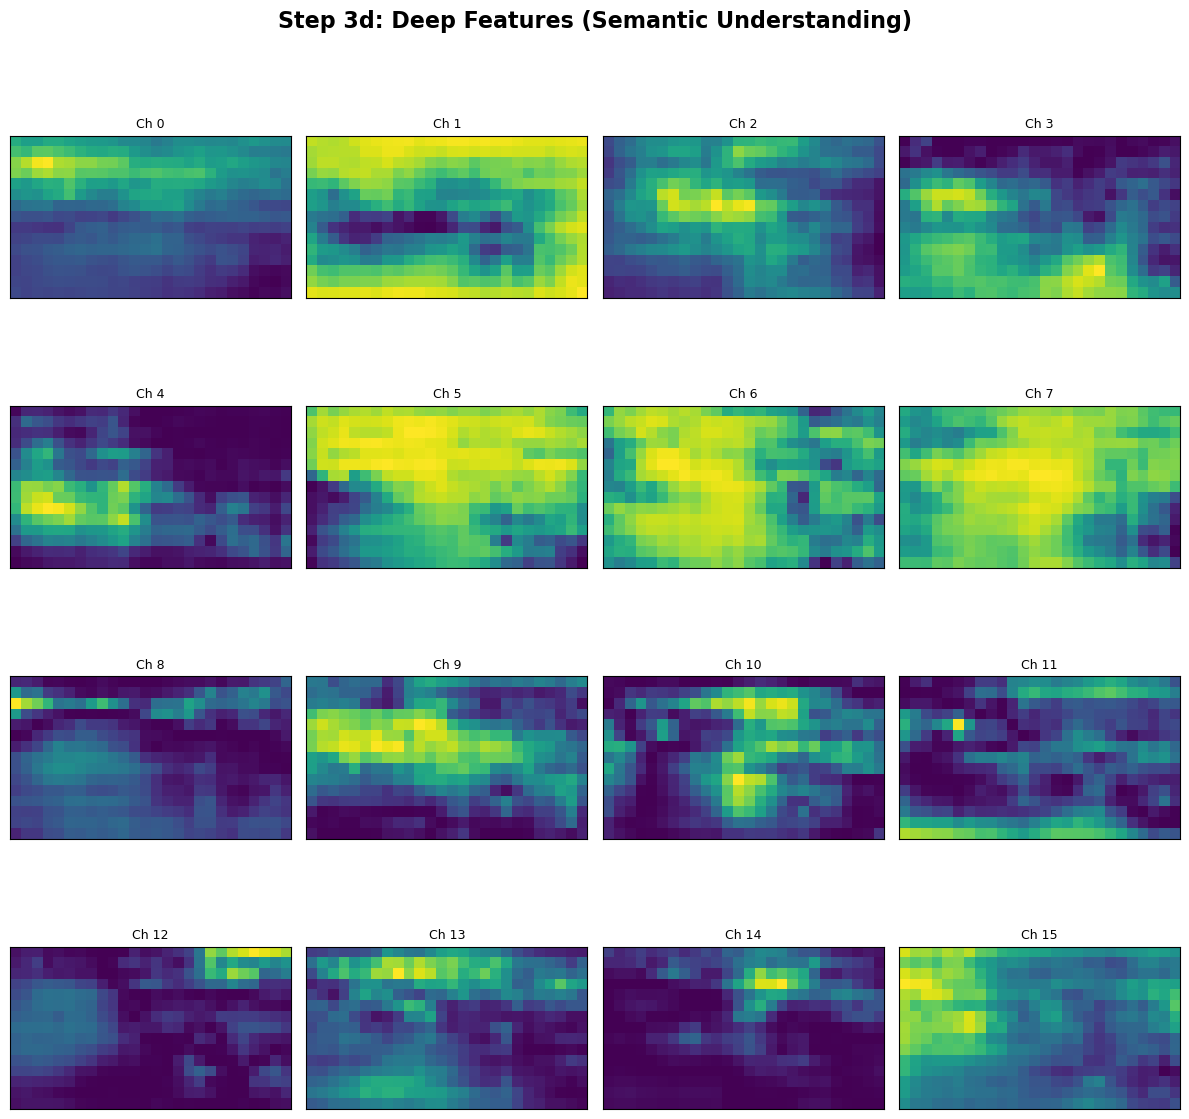

In [5]:
def visualize_feature_map(feature_tensor, title, num_channels=16, filename=None):
    """
    Visualize the first num_channels of a feature map.
    feature_tensor: (batch, channels, height, width)
    """
    # Take first image in batch
    feat = feature_tensor[0].cpu().numpy()
    
    # Select subset of channels
    num_channels = min(num_channels, feat.shape[0])
    
    # Create grid
    rows = 4
    cols = 4
    fig, axes = plt.subplots(rows, cols, figsize=(12, 12))
    fig.suptitle(title, fontsize=16, fontweight='bold', y=0.995)
    
    for idx in range(rows * cols):
        row = idx // cols
        col = idx % cols
        ax = axes[row, col]
        
        if idx < num_channels:
            # Show feature map channel
            channel = feat[idx]
            im = ax.imshow(channel, cmap='viridis')
            ax.set_title(f'Ch {idx}', fontsize=9)
        else:
            ax.axis('off')
        
        ax.set_xticks([])
        ax.set_yticks([])
    
    plt.tight_layout()
    if filename:
        plt.savefig(viz_dir / filename, dpi=150, bbox_inches='tight')
        print("✓ Saved:", viz_dir / filename)
    plt.show()

# Visualize each layer
visualize_feature_map(
    features['early_conv'],
    'Step 3a: Early Convolutional Layer (Edges & Basic Patterns)',
    filename='layer_viz_3a_early_conv.png'
)

visualize_feature_map(
    features['mid_c2f_1'],
    'Step 3b: Mid-Level Features (Object Parts & Textures)',
    filename='layer_viz_3b_mid_features.png'
)

visualize_feature_map(
    features['mid_c2f_3'],
    'Step 3c: High-Level Features (Complex Patterns)',
    filename='layer_viz_3c_high_features.png'
)

visualize_feature_map(
    features['deep_sppf'],
    'Step 3d: Deep Features (Semantic Understanding)',
    filename='layer_viz_3d_deep_features.png'
)

## Step 5: Final Detection Output

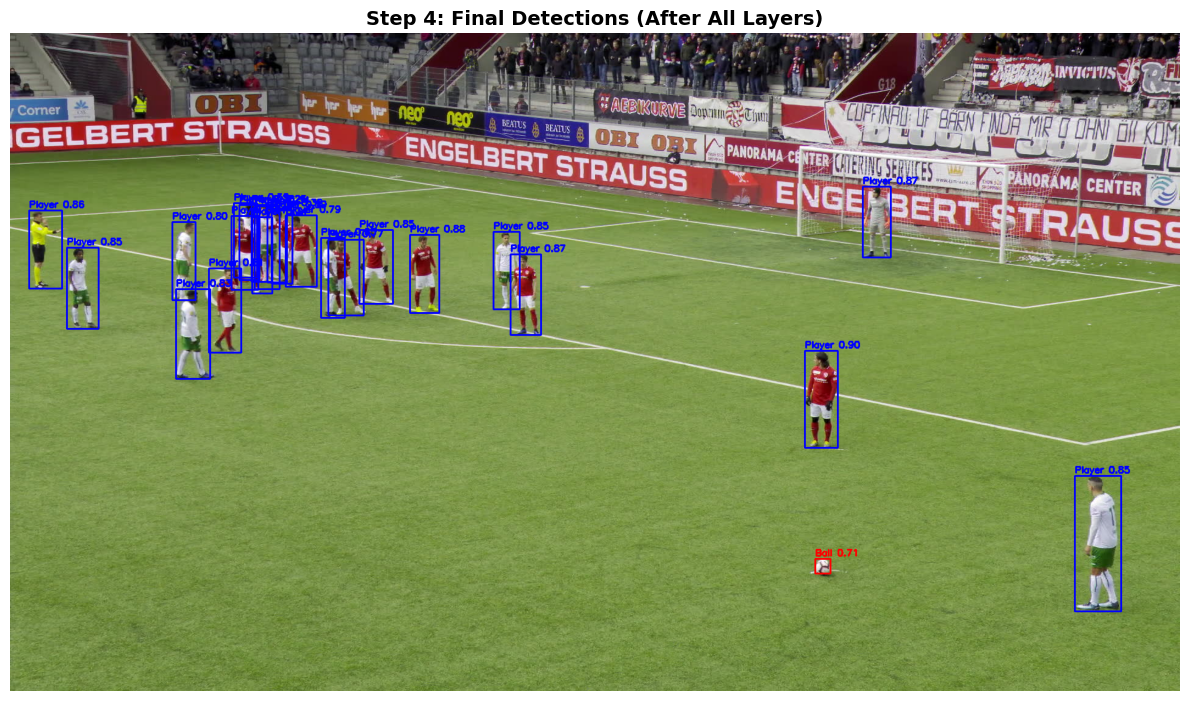

✓ Saved: /Users/yashpatel/Documents/Bocconi/Classes/Year 2/Semester 1/Deep Learning for Computer Vision/Project/Code/visual_comparison/layer_visualizations/layer_viz_4_final_detections.png

Detected 24 objects:
  - Players: 23
  - Balls: 1


In [6]:
# Show final detections
result = results[0]
img_with_boxes = img_rgb.copy()

# Draw bounding boxes
# Note: YOLOv8 already returns boxes in original image coordinates
for box in result.boxes:
    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
    conf = box.conf[0].cpu().item()
    cls = int(box.cls[0].cpu().item())
    
    color = (255, 0, 0) if cls == 1 else (0, 0, 255)  # Red for ball, blue for player
    label = 'Ball' if cls == 1 else 'Player'
    
    cv2.rectangle(img_with_boxes, (int(x1), int(y1)), (int(x2), int(y2)), color, 2)
    cv2.putText(img_with_boxes, f'{label} {conf:.2f}', (int(x1), int(y1)-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.imshow(img_with_boxes)
ax.set_title('Step 4: Final Detections (After All Layers)', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig(viz_dir / 'layer_viz_4_final_detections.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved:", viz_dir / 'layer_viz_4_final_detections.png')

print(f"\nDetected {len(result.boxes)} objects:")
print(f"  - Players: {sum(1 for b in result.boxes if int(b.cls[0]) == 0)}")
print(f"  - Balls: {sum(1 for b in result.boxes if int(b.cls[0]) == 1)}")

## Summary: Complete Pipeline

This notebook generated the following visualization images:

1. **`layer_viz_1_original.png`** - Original input image (1920×1080)
2. **`layer_viz_2_preprocessed.png`** - Resized & letterboxed input (832×832)
3. **`layer_viz_3a_early_conv.png`** - Early layer features (edges, basic patterns)
4. **`layer_viz_3b_mid_features.png`** - Mid-level features (object parts, textures)
5. **`layer_viz_3c_high_features.png`** - High-level features (complex patterns)
6. **`layer_viz_3d_deep_features.png`** - Deep semantic features
7. **`layer_viz_4_final_detections.png`** - Final bounding box predictions

---

### What the Layers Do:

- **Early layers**: Detect basic visual elements (edges, corners, colors)
- **Middle layers**: Combine features into object parts (jerseys, limbs, circular shapes)
- **Deep layers**: Understand high-level semantics ("this is a player", "this is a ball")
- **Detection heads**: Use learned weights to output bounding boxes and classifications